# Psychometric Validation of the DASS-42 Across Populations

This notebook reproduces the full analysis reported in `docs/report.pdf`:

1. **Confirmatory Factor Analysis (CFA)** on a young adult cohort (20–29)
2. **Exploratory Factor Analysis (EFA) → CFA** on an older adult cohort (65–90)
3. **Random Forest classifier** predicting mental state severity from sociodemographic and personality features

Data: [Depression Anxiety Stress Scales Responses](https://www.kaggle.com/datasets/lucasgreenwell/depression-anxiety-stress-scales-responses) (N=39,775, public, anonymized).


In [1]:
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns

from factor_analyzer import FactorAnalyzer
import semopy
from semopy import Model
import pingouin as pg

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option("display.max_columns", 50)


## 1. Data loading & item definitions

The dataset stores each DASS-42 item as three columns: the response (`A`),
its position in the questionnaire (`I`), and the response time in ms (`E`).
We only need the response (`A`) and response time (`E`) columns for the analysis.


In [2]:
df = pd.read_csv('data/data.csv', sep='\t')

# DASS-42 response columns (Q1A..Q42A), response-time columns (Q1E..Q42E), TIPI columns (TIPI1..TIPI10)
dass_items = [f"Q{i}A" for i in range(1, 43)]
dass_response_times = [f"Q{i}E" for i in range(1, 43)]
tipi_items = [f"TIPI{i}" for i in range(1, 11)]

# Original DASS-42 subscale structure (Lovibond & Lovibond, 1995)
DEPRESSION_ITEMS = ["Q3A", "Q5A", "Q10A", "Q13A", "Q16A", "Q17A", "Q21A", "Q24A",
                     "Q26A", "Q31A", "Q34A", "Q37A", "Q38A", "Q42A"]
ANXIETY_ITEMS = ["Q2A", "Q4A", "Q7A", "Q9A", "Q15A", "Q19A", "Q20A", "Q23A",
                  "Q25A", "Q28A", "Q30A", "Q36A", "Q40A", "Q41A"]
STRESS_ITEMS = ["Q1A", "Q6A", "Q8A", "Q11A", "Q12A", "Q14A", "Q18A", "Q22A",
                 "Q27A", "Q29A", "Q32A", "Q33A", "Q35A", "Q39A"]

# TIPI reverse-scored items (Gosling, Rentfrow & Swann, 2003) and trait item pairs
TIPI_REVERSE_ITEMS = ["TIPI2", "TIPI4", "TIPI6", "TIPI8", "TIPI10"]
NEUROTICISM_ITEMS = ["TIPI4", "TIPI9"]     # (4 is reverse-scored -> Emotional Stability -> Neuroticism)
EXTRAVERSION_ITEMS = ["TIPI1", "TIPI6"]    # (6 is reverse-scored)

df.head()


,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,Q4I,Q4E,Q5A,Q5I,Q5E,Q6A,Q6I,Q6E,Q7A,Q7I,Q7E,Q8A,Q8I,Q8E,Q9A,...,VCL7,VCL8,VCL9,VCL10,VCL11,VCL12,VCL13,VCL14,VCL15,VCL16,education,urban,gender,engnat,age,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major
0,4,28,3890,4,25,2122,2,16,1944,4,8,2044,4,34,2153,4,33,2416,4,10,2818,4,13,2259,2,...,1,0,0,1,0,0,0,1,1,1,2,3,2,2,16,1,1,1,12,1,10,2,1,2,NaN
1,4,2,8118,1,36,2890,2,35,4777,3,28,3090,4,10,5078,4,40,2790,3,18,3408,4,1,8342,3,...,0,0,0,1,0,0,0,1,1,1,2,3,2,1,16,2,1,2,7,0,70,2,1,4,NaN
2,3,7,5784,1,33,4373,4,41,3242,1,13,6470,4,11,3927,3,9,3704,1,17,4550,3,5,3021,2,...,0,0,0,0,1,0,0,1,1,1,2,3,2,2,17,2,1,1,4,3,60,1,1,3,NaN
3,2,23,5081,3,11,6837,2,37,5521,1,27,4556,3,28,3269,3,26,3231,4,2,7138,2,19,3079,3,...,0,0,0,1,0,0,0,1,1,1,1,3,2,1,13,2,1,2,4,5,70,2,1,5,biology
4,2,36,3215,2,13,7731,3,5,4156,4,10,2802,4,2,5628,2,9,6522,4,34,2374,4,11,3054,4,...,0,1,0,1,0,0,1,1,1,1,3,2,2,2,19,2,2,3,10,1,10,2,1,4,Psychology


## 2. Reusable analysis functions

The same reliability, validity, and factor-analytic steps are applied to both
age cohorts. Defining them once here avoids duplicating code for each cohort.


In [3]:
def reverse_score(series, max_plus_min=8):
    """Reverse-scores a Likert item (TIPI uses a 1-7 scale, so reversed = 8 - x)."""
    return max_plus_min - series


def score_tipi_traits(tipi_df):
    """Reverse-scores the relevant TIPI items and returns Neuroticism/Extraversion subscale scores."""
    tipi_df = tipi_df.copy()
    tipi_df[TIPI_REVERSE_ITEMS] = tipi_df[TIPI_REVERSE_ITEMS].apply(reverse_score)

    neuroticism = tipi_df[NEUROTICISM_ITEMS]
    extraversion = tipi_df[EXTRAVERSION_ITEMS]
    return neuroticism, extraversion


def reliability_report(subscales: dict):
    """Prints Cronbach's alpha for each named subscale (dict of {name: item_dataframe})."""
    for name, items_df in subscales.items():
        alpha = pg.cronbach_alpha(data=items_df)[0]
        print(f"Cronbach's alpha ({name}): {alpha:.3f}")


def item_total_correlations(items_df):
    """For each item, correlation with the mean of all other items in the same subscale."""
    correlations = {}
    for col in items_df.columns:
        rest_mean = items_df.drop(columns=[col]).mean(axis=1)
        correlations[col] = items_df[col].corr(rest_mean)
    return pd.Series(correlations, name="item_total_r")


def domain_total_correlation(subscale_df, full_items_df, subscale_items):
    """Correlation between a subscale's mean score and the mean of all remaining DASS-42 items."""
    r, p = scipy.stats.pearsonr(
        subscale_df.mean(axis=1),
        full_items_df.drop(columns=subscale_items).mean(axis=1)
    )
    return r, p


def demographic_correlations(scores: dict, df):
    """Pearson/point-biserial correlations between subscale scores and key demographics."""
    results = []
    for name, score in scores.items():
        results.append([f"{name} vs education", *scipy.stats.pearsonr(score, df["education"])])
        results.append([f"{name} vs gender", *scipy.stats.pointbiserialr(score, df["gender"])])
        results.append([f"{name} vs age", *scipy.stats.pearsonr(score, df["age"])])
    return pd.DataFrame(results, columns=["Test", "Correlation Coefficient", "p-value"])


def plot_correlation_heatmap(combined_df, title):
    correlation_matrix = combined_df.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, cmap="coolwarm", annot=True, fmt=".2f")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return correlation_matrix


def fit_cfa(items_df, model_spec):
    """Fits a semopy CFA model and returns the fitted model plus its fit statistics."""
    model = Model(model_spec)
    model.fit(items_df)
    stats = semopy.calc_stats(model)
    return model, stats


def assign_dass_cutoff(df):
    """Assigns a severity level to each row based on standard DASS-42 subscale cutoffs."""
    def get_cutoff(row):
        if row['Dep Score'] <= 9 and row['Anx Score'] <= 7 and row['Str Score'] <= 14:
            return "Normal"
        elif row['Dep Score'] <= 13 or row['Anx Score'] <= 9 or row['Str Score'] <= 18:
            return "Mild"
        elif row['Dep Score'] <= 20 or row['Anx Score'] <= 14 or row['Str Score'] <= 25:
            return "Moderate"
        elif row['Dep Score'] <= 27 or row['Anx Score'] <= 19 or row['Str Score'] <= 33:
            return "Severe"
        else:
            return "Extremely Severe"

    df = df.copy()
    df['cutoff'] = df.apply(get_cutoff, axis=1)
    return df


## 3. Young adults cohort (20–29): Confirmatory Factor Analysis

We test whether the original three-factor DASS-42 structure (Depression,
Anxiety, Stress) holds in a large sample of young adults.


In [4]:
df_young = df[(df["age"] > 20) & (df["age"] < 29)].copy()
print(f"N = {len(df_young)}, age range = {df_young['age'].min()}-{df_young['age'].max()}, "
      f"mean = {df_young['age'].mean():.2f}, SD = {df_young['age'].std():.2f}")

dass_young = df_young[dass_items]
print("\nMissing values per item:", dass_young.isna().sum().sum())


N = 15792, age range = 21-28, mean = 23.46, SD = 2.12

Missing values per item: 0


**Note on Mardia's test**: the Henze-Zirkler implementation builds an N x N
Mahalanobis-distance matrix, which is memory-intensive at N=15,792 (~2GB+).
For reproducibility on standard hardware we run it on a fixed random subsample;
the full-sample result reported in `docs/report.pdf` was HZ=1.84, p<0.05.


In [5]:
# Mardia's test for multivariate normality (subsampled for memory efficiency -- see note above)
mardia_sample = dass_young.sample(n=5000, random_state=42)
mardia = pg.multivariate_normality(mardia_sample, alpha=0.05)
print(mardia)


HZResults(hz=np.float64(1.3507314091690972), pval=np.float64(0.0), normal=False)


In [6]:
cfa_model_spec_young = """
# Latent variables (original DASS-42 structure)
Depression =~ Q3A + Q5A + Q10A + Q13A + Q16A + Q17A + Q21A + Q24A + Q26A + Q31A + Q34A + Q37A + Q38A + Q42A
Anxiety =~ Q2A + Q4A + Q7A + Q9A + Q15A + Q19A + Q20A + Q23A + Q25A + Q28A + Q30A + Q36A + Q40A + Q41A
Stress =~ Q1A + Q6A + Q8A + Q11A + Q12A + Q14A + Q18A + Q22A + Q27A + Q29A + Q32A + Q33A + Q35A + Q39A
"""

cfa_model_young, cfa_stats_young = fit_cfa(dass_young, cfa_model_spec_young)
cfa_stats_young.T


,Value
DoF,816.000000
DoF Baseline,861.000000
chi2,42562.429624
chi2 p-value,0.000000
chi2 Baseline,417174.275749
CFI,0.899724
GFI,0.897974
AGFI,0.892348
NFI,0.897974
TLI,0.894194


In [7]:
# Subscale-level dataframes
dep_young = dass_young[DEPRESSION_ITEMS]
anx_young = dass_young[ANXIETY_ITEMS]
str_young = dass_young[STRESS_ITEMS]

print("Subscale means:", dep_young.mean(axis=1).mean(), anx_young.mean(axis=1).mean(), str_young.mean(axis=1).mean())
print("Subscale SDs:  ", dep_young.mean(axis=1).std(), anx_young.mean(axis=1).std(), str_young.mean(axis=1).std())

reliability_report({"Depression": dep_young, "Anxiety": anx_young, "Stress": str_young})


Subscale means: 2.4671850123027936 2.1060889781444487 2.4779228180633956
Subscale SDs:   0.864635862969239 0.6939384976970333 0.7393431786233535
Cronbach's alpha (Depression): 0.954
Cronbach's alpha (Anxiety): 0.908
Cronbach's alpha (Stress): 0.927


In [8]:
# Item-total correlations (all should be > 0.30 to be considered satisfactory)
print("Depression:\n", item_total_correlations(dep_young), "\n")
print("Anxiety:\n", item_total_correlations(anx_young), "\n")
print("Stress:\n", item_total_correlations(str_young))


Depression:
 Q3A     0.745060
Q5A     0.733787
Q10A    0.788683
Q13A    0.775778
Q16A    0.763737
Q17A    0.770833
Q21A    0.806975
Q24A    0.735379
Q26A    0.741804
Q31A    0.727143
Q34A    0.788603
Q37A    0.759680
Q38A    0.800498
Q42A    0.623235
Name: item_total_r, dtype: float64 

Anxiety:
 Q2A     0.471186
Q4A     0.652345
Q7A     0.667840
Q9A     0.621311
Q15A    0.585041
Q19A    0.510863
Q20A    0.670478
Q23A    0.546129
Q25A    0.621896
Q28A    0.697209
Q30A    0.587387
Q36A    0.667448
Q40A    0.632670
Q41A    0.623703
Name: item_total_r, dtype: float64 

Stress:
 Q1A     0.718635
Q6A     0.670115
Q8A     0.681872
Q11A    0.726949
Q12A    0.643698
Q14A    0.530762
Q18A    0.575821
Q22A    0.682635
Q27A    0.703805
Q29A    0.709237
Q32A    0.650084
Q33A    0.659348
Q35A    0.640649
Q39A    0.691044
Name: item_total_r, dtype: float64


In [9]:
# Domain-total correlations
for name, subscale, items in [("Depression", dep_young, DEPRESSION_ITEMS),
                               ("Anxiety", anx_young, ANXIETY_ITEMS),
                               ("Stress", str_young, STRESS_ITEMS)]:
    r, p = domain_total_correlation(subscale, dass_young, items)
    print(f"{name}: r = {r:.3f}, p = {p:.4f}")


Depression: r = 0.750, p = 0.0000
Anxiety: r = 0.783, p = 0.0000
Stress: r = 0.847, p = 0.0000


In [10]:
# TIPI scoring and criterion validity
tipi_young = df_young[tipi_items]
neuroticism_young, extraversion_young = score_tipi_traits(tipi_young)

reliability_report({"Neuroticism (Emotional Stability)": neuroticism_young, "Extraversion": extraversion_young})

print()
for trait_name, trait_score in [("Neuroticism", neuroticism_young.sum(axis=1)),
                                 ("Extraversion", extraversion_young.sum(axis=1))]:
    for subscale_name, subscale in [("Depression", dep_young), ("Anxiety", anx_young), ("Stress", str_young)]:
        r, p = scipy.stats.pearsonr(trait_score, subscale.sum(axis=1))
        print(f"{trait_name} vs {subscale_name}: r = {r:.3f}, p = {p:.4f}")


Cronbach's alpha (Neuroticism (Emotional Stability)): 0.553
Cronbach's alpha (Extraversion): 0.467

Neuroticism vs Depression: r = -0.501, p = 0.0000
Neuroticism vs Anxiety: r = -0.509, p = 0.0000
Neuroticism vs Stress: r = -0.628, p = 0.0000
Extraversion vs Depression: r = -0.277, p = 0.0000
Extraversion vs Anxiety: r = -0.165, p = 0.0000
Extraversion vs Stress: r = -0.173, p = 0.0000


In [11]:
# Correlations with sociodemographic variables
demographic_correlations(
    {"Depression": dep_young.mean(axis=1), "Anxiety": anx_young.mean(axis=1), "Stress": str_young.mean(axis=1)},
    df_young
)


,Test,Correlation Coefficient,p-value
0,Depression vs education,-0.077819,1.203770e-22
1,Depression vs gender,0.031344,8.164536e-05
2,Depression vs age,-0.018374,2.094252e-02
3,Anxiety vs education,-0.047132,3.108685e-09
4,Anxiety vs gender,0.107953,3.750441e-42
5,Anxiety vs age,-0.073322,2.816206e-20
6,Stress vs education,-0.050480,2.192763e-10
7,Stress vs gender,0.114645,2.382492e-47
8,Stress vs age,-0.032432,4.574405e-05


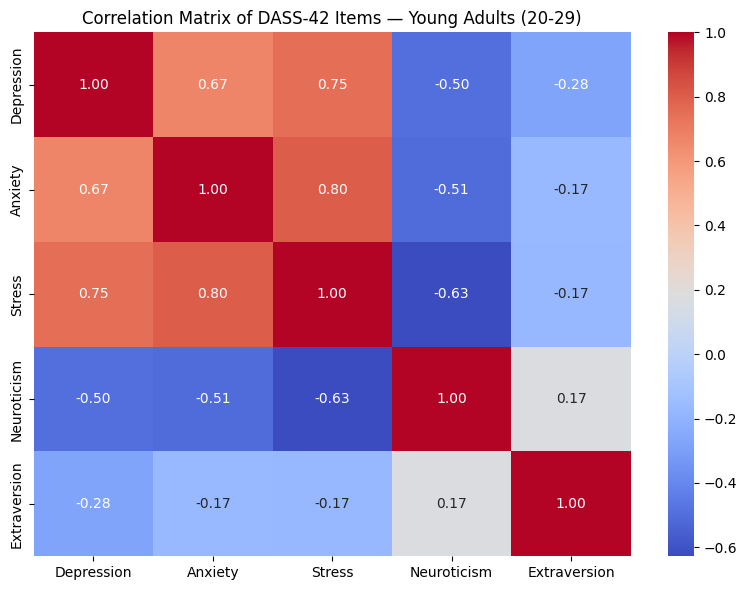

,Depression,Anxiety,Stress,Neuroticism,Extraversion
Depression,1.000000,0.671424,0.751155,-0.500604,-0.277025
Anxiety,0.671424,1.000000,0.804223,-0.509169,-0.165059
Stress,0.751155,0.804223,1.000000,-0.627951,-0.172913
Neuroticism,-0.500604,-0.509169,-0.627951,1.000000,0.172993
Extraversion,-0.277025,-0.165059,-0.172913,0.172993,1.000000


In [12]:
# Full correlation matrix (DASS subscales + personality traits)
combined_young = pd.concat([
    dep_young.mean(axis=1), anx_young.mean(axis=1), str_young.mean(axis=1),
    neuroticism_young.mean(axis=1), extraversion_young.mean(axis=1)
], axis=1)
combined_young.columns = ["Depression", "Anxiety", "Stress", "Neuroticism", "Extraversion"]

plot_correlation_heatmap(combined_young, "Correlation Matrix of DASS-42 Items — Young Adults (20-29)")


## 4. Older adults cohort (65–90): Exploratory → Confirmatory Factor Analysis

We test whether the same three-factor structure generalizes to an older,
smaller subsample, starting from an exploratory approach.


In [13]:
df_old = df[(df["age"] > 60) & (df["age"] < 90)].copy()
print(f"N = {len(df_old)}, age range = {df_old['age'].min()}-{df_old['age'].max()}, "
      f"mean = {df_old['age'].mean():.2f}, SD = {df_old['age'].std():.2f}")

dass_old = df_old[dass_items].copy()


N = 253, age range = 61-89, mean = 66.46, SD = 5.35


In [14]:
# Parallel analysis to determine the number of factors to retain
def parallel_analysis(n_simulations, n_samples, n_variables, n_factors=10):
    all_loadings = []
    for _ in range(n_simulations):
        random_data = np.random.rand(n_samples, n_variables)
        fa_sim = FactorAnalyzer(n_factors=n_factors, rotation="promax", method="principal")
        fa_sim.fit(random_data)
        all_loadings.append(fa_sim.loadings_)
    return np.mean(all_loadings, axis=0)

random_loadings = parallel_analysis(n_simulations=10, n_samples=len(dass_old), n_variables=42)


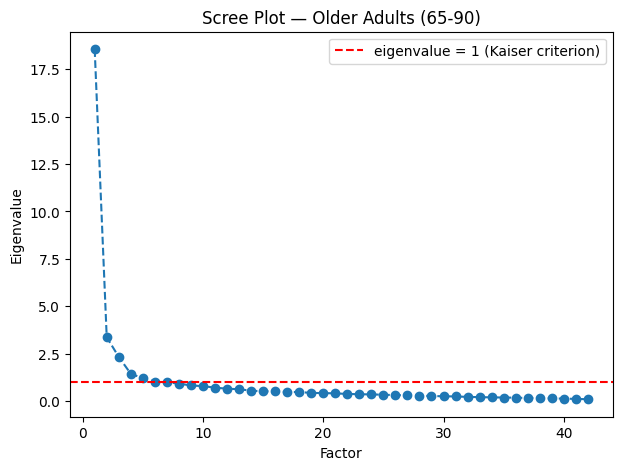

In [15]:
# EFA with ML extraction and Promax (oblique) rotation
fa = FactorAnalyzer(n_factors=10, rotation="promax", method="ml")
fa.fit(dass_old)

eigenvalues, _ = fa.get_eigenvalues()
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='--')
plt.axhline(y=1, color='r', linestyle='--', label='eigenvalue = 1 (Kaiser criterion)')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot — Older Adults (65-90)')
plt.legend()
plt.show()


In [16]:
loadings = pd.DataFrame(fa.loadings_, index=dass_old.columns, columns=[f"Factor {i+1}" for i in range(10)])
variance_total, variance_per_factor, cumulative_variance = fa.get_factor_variance()

variance_summary = pd.DataFrame({
    "Real Eigenvalues": variance_per_factor,
    "Mean Random Eigenvalues (parallel analysis)": random_loadings.mean(axis=0)
})
variance_summary


,Real Eigenvalues,Mean Random Eigenvalues (parallel analysis)
0,0.153325,0.022816
1,0.122530,0.024582
2,0.072781,0.025645
3,0.069248,0.020295
4,0.049117,0.017112
5,0.041933,0.036630
6,0.041272,0.021722
7,0.029872,0.036835
8,0.017508,0.025666
9,0.015464,0.024878


In [17]:
loadings.iloc[:, 0:3]  # loadings on the first three (retained) factors

,Factor 1,Factor 2,Factor 3
Q1A,0.029972,0.836082,-0.163438
Q2A,0.180832,-0.047192,0.096467
Q3A,0.716445,0.021192,0.179884
Q4A,-0.070822,-0.169921,0.235267
Q5A,0.312888,0.036139,-0.051441
Q6A,-0.102783,0.738804,0.042419
Q7A,0.058954,-0.060803,-0.219904
Q8A,0.158961,0.030259,0.909592
Q9A,0.018039,0.043325,0.241573
Q10A,0.767135,0.003348,0.052374


**KMO criterion** (eigenvalue > 1) supports retaining 3 factors. Item loadings on these
factors show the Depression subscale fully replicating the original structure, while
several Anxiety and Stress items show cross-loadings between the two factors — these
are removed before assessing internal consistency, consistent with the original
Lovibond & Lovibond (1995) item set for Depression.


In [18]:
# Revised item sets after removing cross-loading items (see Discussion in docs/report.pdf)
DEPRESSION_ITEMS_OLD = DEPRESSION_ITEMS  # fully replicated, no changes needed
ANXIETY_ITEMS_OLD = ["Q9A", "Q20A", "Q28A", "Q30A", "Q33A", "Q36A", "Q40A", "Q41A"]
STRESS_ITEMS_OLD = ["Q1A", "Q6A", "Q11A", "Q14A", "Q18A", "Q27A", "Q32A", "Q35A", "Q39A"]

CROSS_LOADING_ITEMS = ["Q2A", "Q4A", "Q7A", "Q8A", "Q12A", "Q15A", "Q19A", "Q22A",
                        "Q23A", "Q25A", "Q29A", "Q32A", "Q33A", "Q34A"]

dep_old = dass_old[DEPRESSION_ITEMS_OLD]
anx_old = dass_old[ANXIETY_ITEMS_OLD]
str_old = dass_old[STRESS_ITEMS_OLD]

reliability_report({"Depression": dep_old, "Anxiety": anx_old, "Stress": str_old})


Cronbach's alpha (Depression): 0.966
Cronbach's alpha (Anxiety): 0.879
Cronbach's alpha (Stress): 0.927


In [19]:
# Item-total and domain-total correlations on the revised item sets
print("Depression:\n", item_total_correlations(dep_old), "\n")
print("Anxiety:\n", item_total_correlations(anx_old), "\n")
print("Stress:\n", item_total_correlations(str_old))


Depression:
 Q3A     0.842234
Q5A     0.722893
Q10A    0.834396
Q13A    0.834941
Q16A    0.854179
Q17A    0.783546
Q21A    0.801930
Q24A    0.790802
Q26A    0.792380
Q31A    0.822597
Q34A    0.799707
Q37A    0.813724
Q38A    0.794496
Q42A    0.741905
Name: item_total_r, dtype: float64 

Anxiety:
 Q9A     0.670087
Q20A    0.717468
Q28A    0.780267
Q30A    0.590433
Q33A    0.659364
Q36A    0.646039
Q40A    0.643181
Q41A    0.430007
Name: item_total_r, dtype: float64 

Stress:
 Q1A     0.772780
Q6A     0.726836
Q11A    0.764575
Q14A    0.688127
Q18A    0.776521
Q27A    0.823201
Q32A    0.630543
Q35A    0.668299
Q39A    0.758833
Name: item_total_r, dtype: float64


In [20]:
for name, subscale in [("Depression", dep_old), ("Anxiety", anx_old), ("Stress", str_old)]:
    r = subscale.mean(axis=1).corr(dass_old.mean(axis=1))
    print(f"{name} domain-total correlation: r = {r:.3f}")


Depression domain-total correlation: r = 0.901
Anxiety domain-total correlation: r = 0.849
Stress domain-total correlation: r = 0.822


In [21]:
# TIPI scoring and criterion validity for the older cohort
tipi_old = df_old[tipi_items]
neuroticism_old, extraversion_old = score_tipi_traits(tipi_old)

reliability_report({"Neuroticism (Emotional Stability)": neuroticism_old, "Extraversion": extraversion_old})


Cronbach's alpha (Neuroticism (Emotional Stability)): 0.780
Cronbach's alpha (Extraversion): 0.663


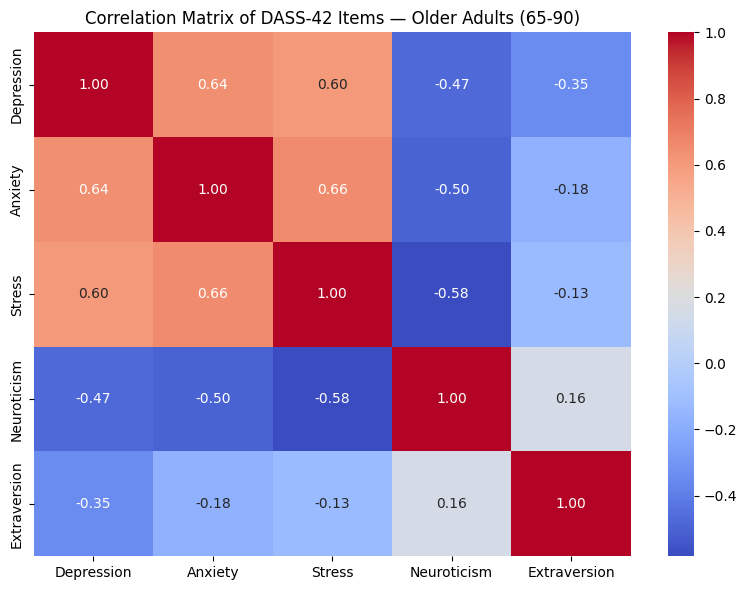

,Depression,Anxiety,Stress,Neuroticism,Extraversion
Depression,1.000000,0.642788,0.601892,-0.472458,-0.346553
Anxiety,0.642788,1.000000,0.655354,-0.500876,-0.177090
Stress,0.601892,0.655354,1.000000,-0.583546,-0.129123
Neuroticism,-0.472458,-0.500876,-0.583546,1.000000,0.156954
Extraversion,-0.346553,-0.177090,-0.129123,0.156954,1.000000


In [22]:
combined_old = pd.concat([
    dep_old.mean(axis=1), anx_old.mean(axis=1), str_old.mean(axis=1),
    neuroticism_old.mean(axis=1), extraversion_old.mean(axis=1)
], axis=1)
combined_old.columns = ["Depression", "Anxiety", "Stress", "Neuroticism", "Extraversion"]

plot_correlation_heatmap(combined_old, "Correlation Matrix of DASS-42 Items — Older Adults (65-90)")


In [23]:
# Confirmatory validation of the revised (cross-loading-free) factor structure
cfa_model_spec_old = """
# Latent variables (revised structure after removing cross-loading items)
Depression =~ Q3A + Q5A + Q10A + Q13A + Q16A + Q17A + Q21A + Q24A + Q26A + Q31A + Q34A + Q37A + Q38A + Q42A
Anxiety =~ Q9A + Q20A + Q28A + Q30A + Q33A + Q36A + Q40A + Q41A
Stress =~ Q1A + Q6A + Q11A + Q14A + Q18A + Q27A + Q32A + Q35A + Q39A
"""

cfa_model_old, cfa_stats_old = fit_cfa(dass_old, cfa_model_spec_old)
cfa_stats_old.T


,Value
DoF,431.000000
DoF Baseline,465.000000
chi2,1113.518460
chi2 p-value,0.000000
chi2 Baseline,6780.605907
CFI,0.891931
GFI,0.835779
AGFI,0.822824
NFI,0.835779
TLI,0.883406


## 5. Random Forest classifier: predicting mental state severity

Using the full sample, we test whether sociodemographic and personality features
can predict a 5-level DASS-42 severity classification (Normal → Extremely Severe).


In [24]:
df_full = pd.read_csv('data/data.csv', sep='\t')

df_full = df_full.assign(
    **{
        "Dep Score": df_full[DEPRESSION_ITEMS].sum(axis=1),
        "Anx Score": df_full[ANXIETY_ITEMS].sum(axis=1),
        "Str Score": df_full[STRESS_ITEMS].sum(axis=1),
        "avg_resp_time": df_full[dass_response_times].mean(axis=1),
    }
)

df_full = assign_dass_cutoff(df_full)
df_full["cutoff"].value_counts()


/tmp/ipykernel_775/2534063877.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_full = df_full.assign(


cutoff
Extremely Severe    19652
Severe              10147
Moderate             7738
Mild                 2238
Name: count, dtype: int64

In [25]:
# Reverse-score TIPI items for the full sample
df_full[TIPI_REVERSE_ITEMS] = df_full[TIPI_REVERSE_ITEMS].apply(reverse_score)

demographic_features = ["age", "married", "engnat", "familysize", "orientation", "education", "avg_resp_time"]
feature_columns = tipi_items + demographic_features

X = df_full[feature_columns]
y = df_full["cutoff"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.5846637335009428

Classification Report:
                   precision    recall  f1-score   support

Extremely Severe       0.68      0.84      0.75      3964
            Mild       0.57      0.27      0.37       450
        Moderate       0.44      0.45      0.45      1515
          Severe       0.39      0.26      0.31      2026

        accuracy                           0.58      7955
       macro avg       0.52      0.45      0.47      7955
    weighted avg       0.56      0.58      0.56      7955

Confusion Matrix:
 [[3314   12  242  396]
 [  42  121  235   52]
 [ 401   63  689  362]
 [1093   16  390  527]]


In [27]:
feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_classifier.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importances


,Feature,Importance
3,TIPI4,0.132033
16,avg_resp_time,0.119586
10,age,0.085214
8,TIPI9,0.084023
13,familysize,0.061094
9,TIPI10,0.055941
7,TIPI8,0.054783
1,TIPI2,0.053095
5,TIPI6,0.052257
0,TIPI1,0.051581
